<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-3-290czeslaw/blob/main/lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Wczytanie i analiza danych

In [4]:
hd = pd.read_csv("sample_data/Heart_disease_cleveland_new.csv")

hd.shape
hd.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


## Opis danych

Age - Wiek pacjenta w latach (Numeryczna)

Sex - Płeć (Mężczyzna - 1; Kobieta - 0) (Nominalna)

cp - Rodzaj bólu w klatce piersiowej odczuwanego przez pacjenta. Zmienna podzielona na 4 kategorie. 0 typowa dławica piersiowa, 1 nietypowa dławica piersiowa, 2 ból niedławicowy, 3 bezobjawowy (Nominalna)

trestbps - Poziom ciśnienia krwi pacjenta w spoczynku w mm/Hg (Numeryczna)

chol - Cholesterol w surowicy w mg/dl (Numeryczna)

fbs - Poziom cukru we krwi na czczo > 120 mg/dl reprezentowany jako 1 w przypadku prawdy i 0 jako fałsz (Nominalna)

restecg - Wynik elektrokardiogramu w spoczynku reprezentowany w 3 różnych wartościach. 0 - W normie 1 - posiadający nieprawidłowość załamka ST-T (odwrócenie załamka T i/lub uniesienie lub obniżenie odcinka ST o > 0.05 mV) 2 - wykazujący prawdopodobny lub pewny przerost lewej komory według kryteriów Estesa (Nominalna)

thalach - Maksymalne osiągnięte tętno (Numeryczna)

exang - Dławica piersiowa wywołana wysiłkiem fizycznym 0 oznacza NIE 1 oznacza TAK (Nominalna)

oldpeak - Obniżenie odcinka ST wywołane wysiłkiem fizycznym w stosunku do stanu spoczynku (Numeryczna)

slope - Odcinek ST mierzony pod kątem nachylenia podczas szczytowego wysiłku. 0 - nachylenie w górę; 1 - płaski; 2 - nachylenie w dół (Nominalna)

ca - Liczba głównych naczyń (0–3) (Nominalna)

thal - Zaburzenie krwi zwane talasemią. 0 - BRAK (NULL) 1 - prawidłowy przepływ krwi 2 - stały defekt (brak przepływu krwi w pewnej części serca) 3 - odwracalny defekt (przepływ krwi jest obserwowany, ale nie jest prawidłowy) (Nominalna)

target - Jest to zmienna docelowa, którą musimy przewidzieć. 1 oznacza, że pacjent cierpi na chorobę serca, a 0 oznacza, że pacjent jest zdrowy.

## Analiza korelacji

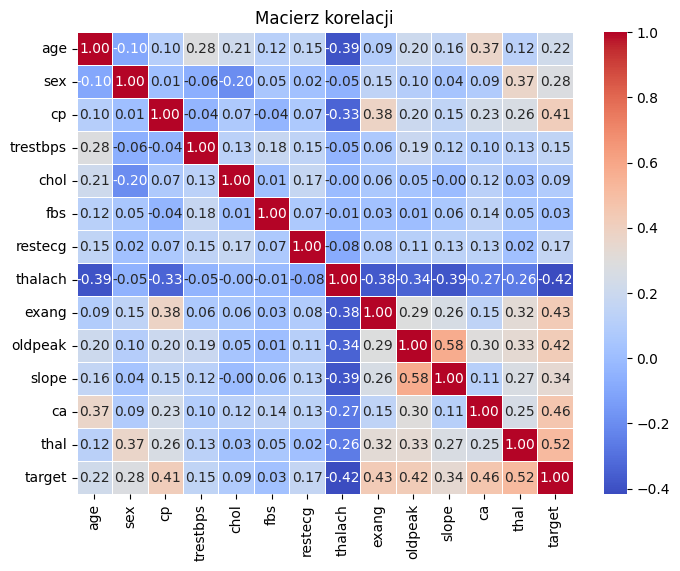

In [5]:
macierz_korelacji = hd.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    data=macierz_korelacji,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Macierz korelacji")
plt.show()

## Sprawdzenie rozkładu kolumny "target"

In [6]:
print(hd['target'].value_counts(normalize=True))

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


## Podział na zbiór testowy i treningowy

In [7]:
from sklearn.model_selection import train_test_split


X = hd.drop('target', axis=1)
y = hd['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#2. Trenowanie instancji modelu regresji logistycznej

In [8]:
from sklearn.linear_model import LogisticRegression

# Inicjalizacja
model_base = LogisticRegression(max_iter=5000)
model_base.fit(X_train, y_train)

# Predykcje
y_pred = model_base.predict(X_test)
y_probs = model_base.predict_proba(X_test)[:, 1] # Prawdopodobieństwa dla klasy pozytywnej (1)

#3. Ocena działania modelu

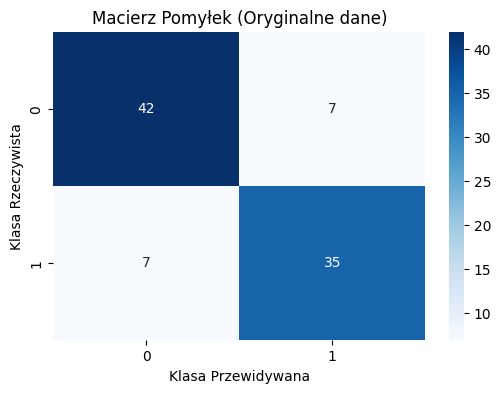

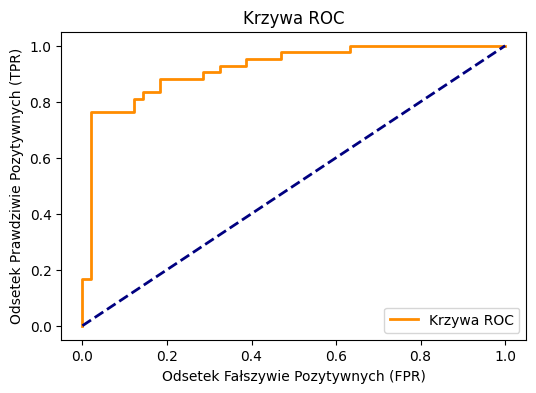


--- Wybrane Metryki ---
Precyzja (Precision): 0.8333
Czułość (Recall): 0.8333


In [9]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, recall_score, precision_score, accuracy_score

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Klasa Przewidywana')
plt.ylabel('Klasa Rzeczywista')
plt.title('Macierz Pomyłek (Oryginalne dane)')
plt.show()

# Krzywa ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Krzywa ROC')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Odsetek Fałszywie Pozytywnych (FPR)')
plt.ylabel('Odsetek Prawdziwie Pozytywnych (TPR)')
plt.title('Krzywa ROC')
plt.legend(loc="lower right")
plt.show()

# Wybrane metryki
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n--- Wybrane Metryki ---")
print(f"Precyzja (Precision): {precision:.4f}")
print(f"Czułość (Recall): {recall:.4f}")

a) Macierz Pomyłek

Prawdziwie Pozytywne (TP - prawy dolny róg): Model przewidział chorobę, a pacjent faktycznie jest chory.

Prawdziwie Negatywne (TN - lewy górny róg): Model przewidział brak choroby, a pacjent faktycznie nie jest chory.

Fałszywie Pozytywne (FP - prawy górny róg): Model zdiagnozował chorobę, ale pacjent jest zdrowy. Pacjent zostanie wysłany na niepotrzebne, dodatkowe badania, ale wynik nie zagraża bezpośrednio jego życiu.

Fałszywie Negatywne (FN - lewy dolny róg): Model stwierdził, że pacjent jest zdrowy, ale w rzeczywistości jest chory. To najniebezpieczniejszy błąd.

b) Krzywa ROC - mówi na ile możena zwiększyć czułość modelu, zanim zacznie on generować drastyczną liczbę fałszywych alarmów. Widać, że wytrenowany model jest zdecydowanie lepszy niż losowe zgadywanie

c) Czułość (Recall) - mówi o tym, jaki procent osób z faktycznie chorym sercem został przez nasz model poprawnie wyłapany. Jest wysoka ale nie wystarczająca do uznania tego modelu za skuteczny (za dużo występuje przypadków gdzie ktoś był chory, a model uznał, że nie jest)

Precyzja (Precision) - mówi o tym, jaki procent pacjentów, którym model przypisał chorobę (1), rzeczywiście na nią cierpi. Wyosni około 83% co jest  dobrym wynikiem i w tym kontekście nie jest aż tak istotny jak czułość.


# 4. Standaryzacja i Normalizacja

Accuracy (Brak skalowania): 0.8462
Accuracy (Standaryzacja):   0.8352
Accuracy (Normalizacja):    0.8242


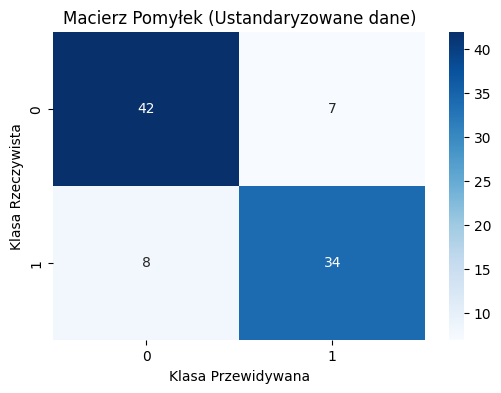

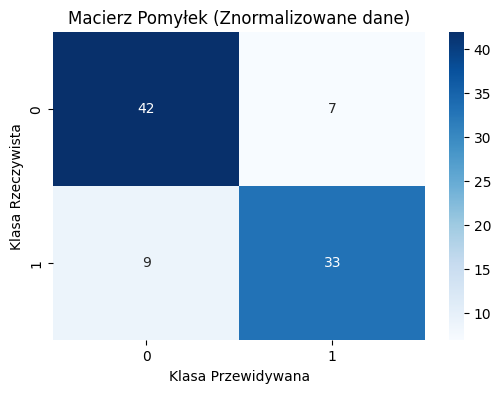

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

# Standaryzacja
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

# Normalizacja (Min-Max)
X_train_norm = scaler_minmax.fit_transform(X_train)
X_test_norm = scaler_minmax.transform(X_test)

# Modele
model_std = LogisticRegression(max_iter=5000).fit(X_train_std, y_train)
model_norm = LogisticRegression(max_iter=5000).fit(X_train_norm, y_train)

print(f"Accuracy (Brak skalowania): {accuracy_score(y_test, y_pred):.4f}")
print(f"Accuracy (Standaryzacja):   {accuracy_score(y_test, model_std.predict(X_test_std)):.4f}")
print(f"Accuracy (Normalizacja):    {accuracy_score(y_test, model_norm.predict(X_test_norm)):.4f}")

cm = confusion_matrix(y_test, model_std.predict(X_test_std))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Klasa Przewidywana')
plt.ylabel('Klasa Rzeczywista')
plt.title('Macierz Pomyłek (Ustandaryzowane dane)')
plt.show()

cm = confusion_matrix(y_test, model_norm.predict(X_test_norm))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Klasa Przewidywana')
plt.ylabel('Klasa Rzeczywista')
plt.title('Macierz Pomyłek (Znormalizowane dane)')
plt.show()

Standaryzacja i normalizacja wpłynęła negatywnie na działanie modelu, co może wynikać z małej ilości danych.

# 5. Zmiana parametrów (siła regularyzacji, l1_ratio)

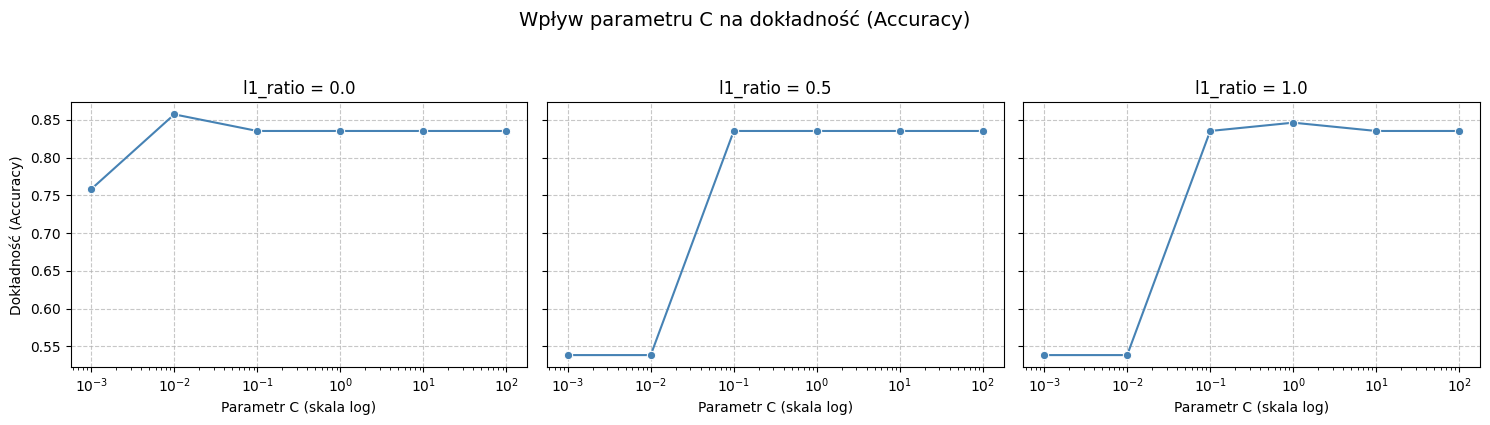

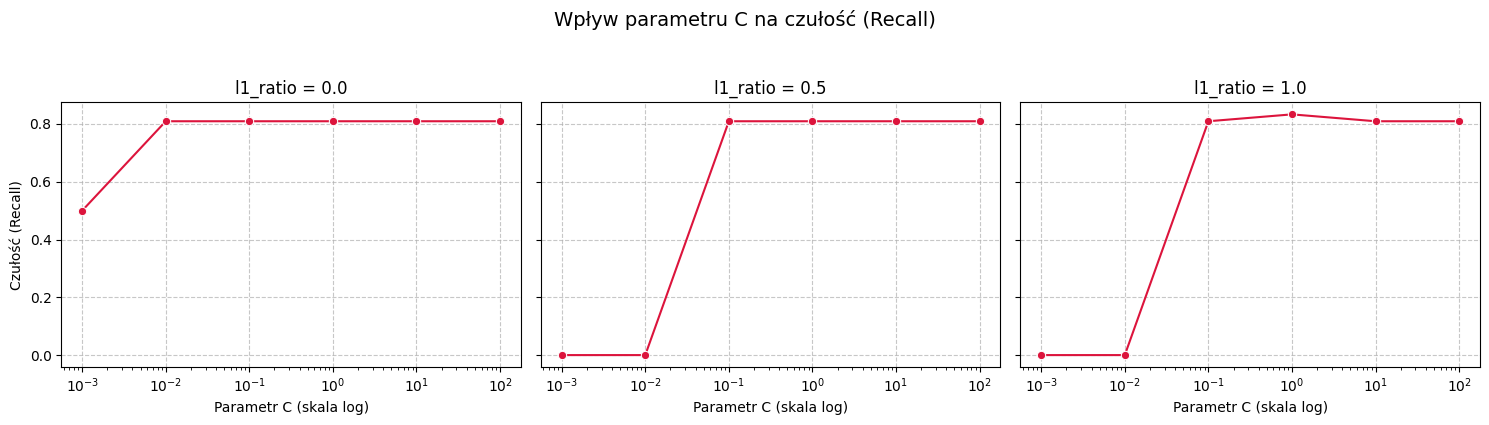

Tabela 1 - Dokładność (Accuracy):


l1_ratio,0.0,0.5,1.0
C,,,
0.001,0.7582,0.5385,0.5385
0.010,0.8571,0.5385,0.5385
0.100,0.8352,0.8352,0.8352
1.000,0.8352,0.8352,0.8462
10.000,0.8352,0.8352,0.8352
100.000,0.8352,0.8352,0.8352



Tabela 2 - Czułość (Recall):


l1_ratio,0.0,0.5,1.0
C,,,
0.001,0.5000,0.0000,0.0000
0.010,0.8095,0.0000,0.0000
0.100,0.8095,0.8095,0.8095
1.000,0.8095,0.8095,0.8333
10.000,0.8095,0.8095,0.8095
100.000,0.8095,0.8095,0.8095


In [43]:
c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
l1_values = [0.0, 0.5, 1.0]
results = []

for c in c_values:
    for l1 in l1_values:
        model = LogisticRegression(penalty='elasticnet', solver='saga', C=c, l1_ratio=l1, max_iter=5000, random_state=42)
        model.fit(X_train_std, y_train)
        acc = model.score(X_test_std, y_test)
        y_pred = model.predict(X_test_std)
        rec = recall_score(y_test, y_pred)
        results.append({'C': c, 'l1_ratio': l1, 'Accuracy': acc, 'Recall': rec})
df_results = pd.DataFrame(results)

fig_acc, axes_acc = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig_acc.suptitle('Wpływ parametru C na dokładność (Accuracy)', fontsize=14, y=1.05)
for i, l1 in enumerate(l1_values):
    subset = df_results[df_results['l1_ratio'] == l1]
    sns.lineplot(data=subset, x='C', y='Accuracy', marker='o', ax=axes_acc[i], color='steelblue')
    axes_acc[i].set_xscale('log')
    axes_acc[i].set_title(f'l1_ratio = {l1}')
    axes_acc[i].set_xlabel('Parametr C (skala log)')
    if i == 0:
        axes_acc[i].set_ylabel('Dokładność (Accuracy)')
    axes_acc[i].grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

fig_rec, axes_rec = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig_rec.suptitle('Wpływ parametru C na czułość (Recall)', fontsize=14, y=1.05)
for i, l1 in enumerate(l1_values):
    subset = df_results[df_results['l1_ratio'] == l1]
    sns.lineplot(data=subset, x='C', y='Recall', marker='o', ax=axes_rec[i], color='crimson')
    axes_rec[i].set_xscale('log')
    axes_rec[i].set_title(f'l1_ratio = {l1}')
    axes_rec[i].set_xlabel('Parametr C (skala log)')
    if i == 0:
        axes_rec[i].set_ylabel('Czułość (Recall)')
    axes_rec[i].grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Tabela 1 - Dokładność (Accuracy):")
df_pivot_acc = df_results.pivot(index='C', columns='l1_ratio', values='Accuracy')
display(df_pivot_acc.round(4))

print("\nTabela 2 - Czułość (Recall):")
df_pivot_rec = df_results.pivot(index='C', columns='l1_ratio', values='Recall')
display(df_pivot_rec.round(4))

Dla zmiennej C (siła odwrotności regularyzaji) wartość 0,1 jest progiem powyżej którego, zwiększanie wartości nie wpływa na accuracy. Im mniejsze C, tym accuracy jest zazwyczaj gorsze.

l1 ratio na poziomie 0.0 jest najlepsze w większości przypadków

Wyjątkiem od powyższych reguł jest C = 1 i l1_ratio = 1 (dokładność 0.8462), oraz C = 0.01 i l1_ratio = 0 (dokładność 0.8571)

## Liczba iteracji

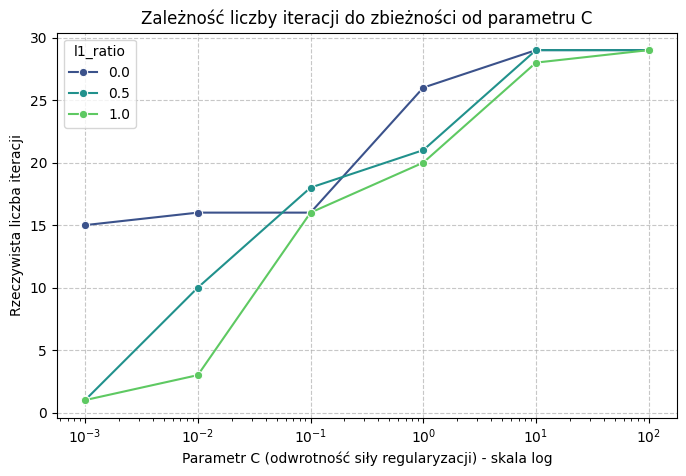


Szczegółowe wyniki (Liczba iteracji) dla poszczególnych parametrów:


l1_ratio,0.0,0.5,1.0
C,,,
0.001,15,1,1
0.010,16,10,3
0.100,16,18,16
1.000,26,21,20
10.000,29,29,28
100.000,29,29,29


In [47]:
c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
l1_values = [0.0, 0.5, 1.0]
iter_results = []

for c in c_values:
    for l1 in l1_values:
        model = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            C=c,
            l1_ratio=l1,
            max_iter=5000,
            random_state=42
        )
        model.fit(X_train_std, y_train)
        actual_iters = model.n_iter_[0]
        iter_results.append({'C': c, 'l1_ratio': l1, 'Iteracje': actual_iters})
df_iters = pd.DataFrame(iter_results)

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_iters, x='C', y='Iteracje', hue=df_iters['l1_ratio'].astype(str), marker='o', palette='viridis')
plt.xscale('log')
plt.title('Zależność liczby iteracji do zbieżności od parametru C')
plt.xlabel('Parametr C (odwrotność siły regularyzacji) - skala log')
plt.ylabel('Rzeczywista liczba iteracji')
plt.legend(title='l1_ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nSzczegółowe wyniki (Liczba iteracji) dla poszczególnych parametrów:")
df_pivot_iters = df_iters.pivot(index='C', columns='l1_ratio', values='Iteracje')
display(df_pivot_iters)

Im większa wartość parametru C (czyli siła regularyzacji jest mniejsza), tym jest większa liczba iteracji. Drugorzędną cechą jest parametr l1_ratio, który oddziałowuje analogicznie, lecz słabiej.

# 6. Walidacja krzyżowa

Liczba podziałów      Rodzaj_CV  Średnia Dokładność  Zmienność (Odchylenie Std)
         10-fold Stratyfikowane              0.8345                      0.0673
         10-fold  Zwykłe K-Fold              0.8383                      0.0570
          2-fold Stratyfikowane              0.8184                      0.0148
          2-fold  Zwykłe K-Fold              0.8251                      0.0055
          5-fold Stratyfikowane              0.8316                      0.0554
          5-fold  Zwykłe K-Fold              0.8415                      0.0328


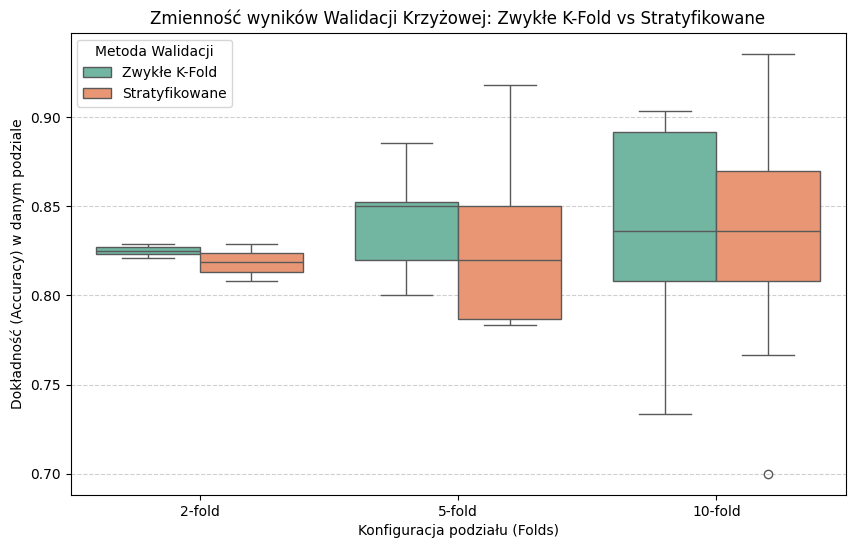

In [40]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

folds_list = [2, 5, 10]
cv_results = []

for k in folds_list:
    # KFold
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores_kf = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')

    for score in scores_kf:
        cv_results.append({'Liczba podziałów': f'{k}-fold', 'Rodzaj_CV': 'Zwykłe K-Fold', 'Accuracy': score})

    # StratifiedKFold
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores_skf = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')

    for score in scores_skf:
         cv_results.append({'Liczba podziałów': f'{k}-fold', 'Rodzaj_CV': 'Stratyfikowane', 'Accuracy': score})

df_cv = pd.DataFrame(cv_results)

summary_table = df_cv.groupby(['Liczba podziałów', 'Rodzaj_CV'])['Accuracy'].agg(['mean', 'std']).reset_index()
summary_table.rename(columns={'mean': 'Średnia Dokładność', 'std': 'Zmienność (Odchylenie Std)'}, inplace=True)
print(summary_table.round(4).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cv, x='Liczba podziałów', y='Accuracy', hue='Rodzaj_CV', palette='Set2')
plt.title('Zmienność wyników Walidacji Krzyżowej: Zwykłe K-Fold vs Stratyfikowane')
plt.ylabel('Dokładność (Accuracy) w danym podziale')
plt.xlabel('Konfiguracja podziału (Folds)')
plt.legend(title='Metoda Walidacji')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()